In [ ]:
# Install dependencies
!apt-get install -y coinor-libipopt-dev
!pip install pyomo

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
coinor-libipopt-dev is already the newest version (3.11.9-2.2build5).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

In [ ]:
# Check IPOPT is installed
!which ipopt
!ipopt --version

bin/ipopt
Ipopt 3.13.2 (x86_64-pc-linux-gnu), ASL(20190605)



In [ ]:
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
a0_star, a1_star = 3.8, 4
b0_star, b1_star = -3.2, -4
sigma0, sigma1 = 0.1, 0.5
c = 0.1

p0_star = -a0_star/(2*b0_star) + c/2
print(p0_star)
print(p0_star * p0_star)

EP2_0 = 0.06

0.6437499999999999
0.4144140624999999


In [ ]:
import math

def solve_b(alpha, sigma0, sigma1, EP2_0, b0_true, tol=1e-15):
    """Return real closed-form solutions for b, given:
       (b - b0_true)^2 * EP2_0 + sigma0^2 = (1 - alpha) * sigma0^2 + alpha * sigma1^2
    """
    if EP2_0 <= 0:
        raise ValueError("EP2_0 must be > 0 for real solutions.")
    radicand = alpha * (sigma1**2 - sigma0**2) / EP2_0
    if radicand < -tol:
        return []  # no real solution
    r = 0.0 if abs(radicand) <= tol else math.sqrt(max(0.0, radicand))
    b_plus  = b0_true + r
    b_minus = b0_true - r
    return [b_minus, b_plus] if r > 0 else [b0_true]

# Example
alpha = 1
print(solve_b(alpha, sigma0, sigma1, EP2_0, b0_star))

[-5.2, -1.2000000000000002]


In [ ]:
def metrics(p0, p1, c, a0_star, a1_star, b0_star, b1_star):
  d0 = max(a0_star + b0_star * p0, 0)
  d1 = max(a1_star + b1_star * p1, 0)
  profit = (p0-c) * d0 + (p1-c) * d1
  surplus = -1/(2*b0_star) + pow(d0,2) + -1/(2*b1_star) + pow(d1,2)
  welfare = profit + surplus
  return profit, surplus, welfare, d0/a0_star, d1/a1_star

In [ ]:
R_minus_alpha, R_plus_alpha = [], []
S_minus_alpha, S_plus_alpha = [], []
p0_minus_alpha, p1_alpha = [], []
d0_minus_alpha, d1_alpha = [], []

alpha_range = np.linspace(0,1,201)
for alpha in alpha_range:
  if alpha == 0:
    b0_minus = b0_star
    b0_plus = b0_star
  else:
    b0_minus, b0_plus = solve_b(alpha, sigma0, sigma1, EP2_0, b0_star)
  p0_minus, p0_plus, p1_star = -a0_star/(2*b0_minus), -a0_star/(2*b0_plus), -a1_star/(2*b1_star)

  r_plus, s_plus, w_plus, _, _ = metrics(p0_plus, p1_star, c, a0_star, a1_star, b0_star, b1_star)
  r_minus, s_minus, w_minus, d0_minus, d1 = metrics(p0_minus, p1_star, c, a0_star, a1_star, b0_star, b1_star)

  R_minus_alpha.append(r_minus)
  S_minus_alpha.append(s_minus)
  R_plus_alpha.append(r_plus)
  S_plus_alpha.append(s_plus)

  p0_minus_alpha.append(p0_minus)
  p1_alpha.append(p1_star)
  d0_minus_alpha.append(d0_minus)
  d1_alpha.append(d1)

In [ ]:
def legend_above(ax, ncol=3, fontsize=14, pad=0.02):
    ax.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1 + pad),
        bbox_transform=ax.transAxes,
        ncol=ncol,
        fontsize=fontsize,
        frameon=True,
        borderaxespad=0.0,
        columnspacing=1.0,
        handlelength=1.5,
        handletextpad=0.4,
        labelspacing=0.4
    )

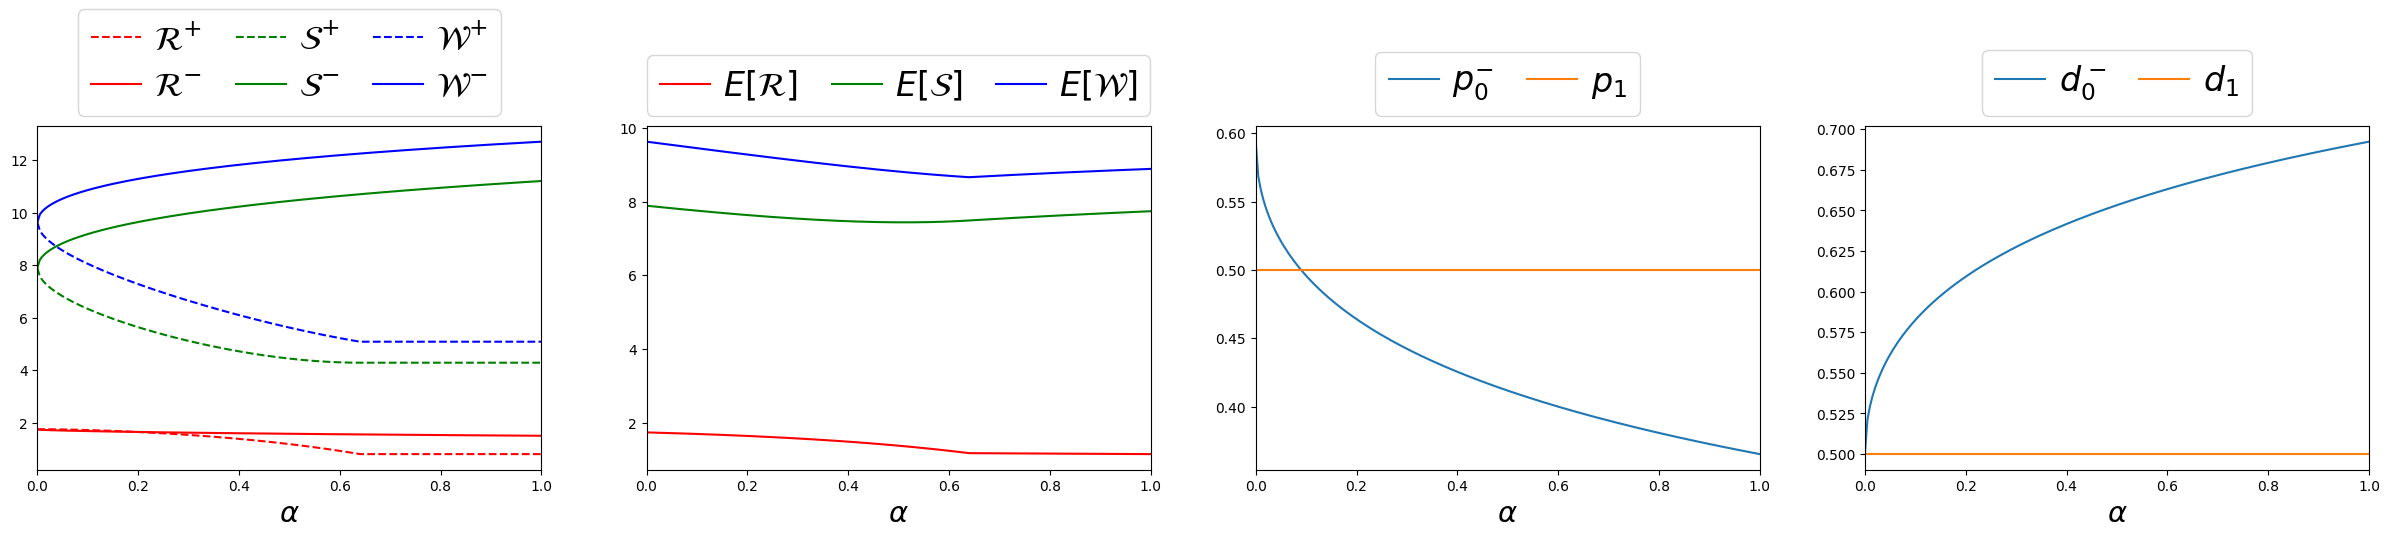

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5.5))

# Plot: Metrics
axes[0].plot(alpha_range, R_plus_alpha, label=r'$\mathcal{R}^{+}$', color ='red', linestyle='--')
axes[0].plot(alpha_range, R_minus_alpha, label=r'$\mathcal{R}^{-}$', color ='red', linestyle='-')
axes[0].plot(alpha_range, S_plus_alpha, label=r'$\mathcal{S}^{+}$', color ='green', linestyle='--')
axes[0].plot(alpha_range, S_minus_alpha, label=r'$\mathcal{S}^{-}$', color ='green', linestyle='-')

axes[0].plot(alpha_range, [R_plus_alpha[i]+S_plus_alpha[i] for i in range(len(S_plus_alpha))], label=r'$\mathcal{W}^{+}$', color ='blue', linestyle='--')
axes[0].plot(alpha_range, [R_minus_alpha[i]+S_minus_alpha[i] for i in range(len(S_plus_alpha))], label=r'$\mathcal{W}^{-}$', color ='blue', linestyle='-')

axes[1].plot(alpha_range, [1/2*R_plus_alpha[i] + 1/2*R_minus_alpha[i] for i in range(len(R_plus_alpha))], label=r'$E[\mathcal{R}]$', color ='red')#, linestyle='--')
axes[1].plot(alpha_range, [1/2*S_plus_alpha[i] + 1/2*S_minus_alpha[i] for i in range(len(R_plus_alpha))], label=r'$E[\mathcal{S}]$', color ='green')
axes[1].plot(alpha_range, [1/2*(R_plus_alpha[i]+S_plus_alpha[i]) + 1/2*(R_minus_alpha[i]+S_minus_alpha[i]) for i in range(len(R_plus_alpha))], label=r'$E[\mathcal{W}]$', color ='blue')

axes[2].plot(alpha_range, p0_minus_alpha, label=r'$p_0^{-}$', color='tab:blue', linestyle='-')
axes[2].plot(alpha_range, p1_alpha, label=r'$p_1$', color='tab:orange')

axes[3].plot(alpha_range, d0_minus_alpha, label=r'$d_0^-$', color='tab:blue', linestyle='-')
axes[3].plot(alpha_range, d1_alpha, label=r'$d_1$', color='tab:orange')

# Common settings
for i in range(4):
    axes[i].set_xlim([min(alpha_range), max(alpha_range)])
    axes[i].set_xlabel(r'$\alpha$', fontsize=21)

legend_above(axes[0], ncol=3, fontsize=24, pad=0.03)
legend_above(axes[1], ncol=3, fontsize=24, pad=0.03)
legend_above(axes[2], ncol=3, fontsize=24, pad=0.03)
legend_above(axes[3], ncol=3, fontsize=24, pad=0.03)

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

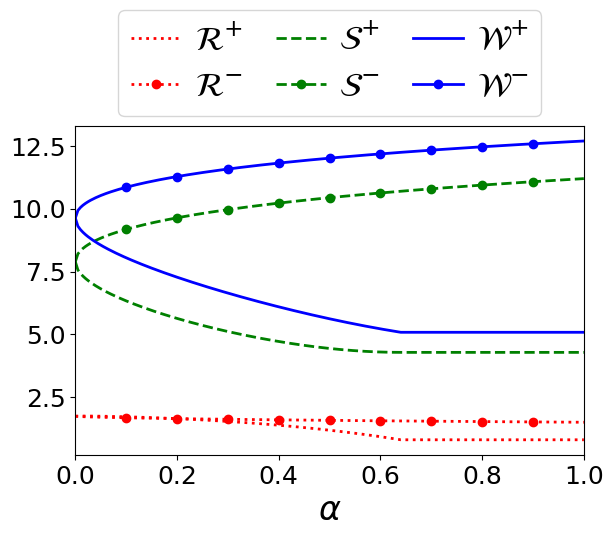

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Your setup ---
# Assuming alpha_range is a numpy array. If not: alpha_range = np.array(alpha_range)
fig, ax = plt.subplots(figsize=(6, 5.5))

# 1. Define the marker locations (at 0.1, 0.2, ..., 0.9)
marker_alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# Find the closest indices in your data to these alpha values
marker_inds = [np.abs(alpha_range - a).argmin() for a in marker_alphas]

# 2. Plot R (Red) - Markers on Minus
ax.plot(alpha_range, R_plus_alpha, label=r'$\mathcal{R}^{+}$',
        color='red', linestyle=':', linewidth=2)
ax.plot(alpha_range, R_minus_alpha, label=r'$\mathcal{R}^{-}$',
        color='red', linestyle=':', marker='o', markevery=marker_inds, linewidth=2)

# 3. Plot S (Green) - Markers on Minus
ax.plot(alpha_range, S_plus_alpha, label=r'$\mathcal{S}^{+}$',
        color='green', linestyle='--', linewidth=2)
ax.plot(alpha_range, S_minus_alpha, label=r'$\mathcal{S}^{-}$',
        color='green', linestyle='--', marker='o', markevery=marker_inds, linewidth=2)

# 4. Plot W (Blue) - Markers on Minus
# W is calculated as R + S
W_plus = [r + s for r, s in zip(R_plus_alpha, S_plus_alpha)]
W_minus = [r + s for r, s in zip(R_minus_alpha, S_minus_alpha)]

ax.plot(alpha_range, W_plus, label=r'$\mathcal{W}^{+}$',
        color='blue', linestyle='-', linewidth=2)
ax.plot(alpha_range, W_minus, label=r'$\mathcal{W}^{-}$',
        color='blue', linestyle='-', marker='o', markevery=marker_inds, linewidth=2)

# --- Formatting ---
ax.set_xlim([min(alpha_range), max(alpha_range)])
ax.set_xlabel(r'$\alpha$', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=18)

# Using your custom legend function
legend_above(ax, ncol=3, fontsize=24, pad=0.03)

plt.tight_layout()

# Save the figure to the Colab environment's local storage
plt.savefig('ML_fairness_1.pdf', format='pdf', bbox_inches='tight')

files.download('ML_fairness_1.pdf')


plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

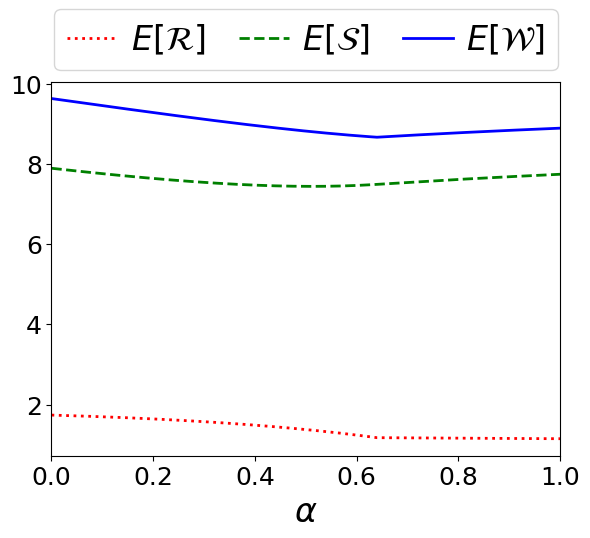

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5.5))

ax.plot(
    alpha_range,
    [0.5 * R_plus_alpha[i] + 0.5 * R_minus_alpha[i] for i in range(len(R_plus_alpha))],
    label=r'$E[\mathcal{R}]$', linestyle=':',
    color='red', linewidth=2
)
ax.plot(
    alpha_range,
    [0.5 * S_plus_alpha[i] + 0.5 * S_minus_alpha[i] for i in range(len(R_plus_alpha))],
    label=r'$E[\mathcal{S}]$',
    linestyle='--',
    color='green', linewidth=2
)
ax.plot(
    alpha_range,
    [0.5 * (R_plus_alpha[i] + S_plus_alpha[i]) + 0.5 * (R_minus_alpha[i] + S_minus_alpha[i]) for i in range(len(R_plus_alpha))],
    label=r'$E[\mathcal{W}]$',
    linestyle='-',
    color='blue', linewidth=2
)

ax.set_xlim([min(alpha_range), max(alpha_range)])
ax.set_xlabel(r'$\alpha$', fontsize=24)

legend_above(ax, ncol=3, fontsize=24, pad=0.03)
ax.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()

# 1. Save the figure to the Colab environment's local storage
plt.savefig('ML_fairness_2.pdf', format='pdf', bbox_inches='tight')

# 2. Import the Colab-specific tool to download the file to your computer
from google.colab import files
files.download('ML_fairness_2.pdf')

# 3. (Optional) Still show the plot in the notebook
plt.show()